# Part 5 walkthrough — independent evaluation

`run_part5.py` computes everything in this notebook, and all the logic is in `part5.py`. Every fit and checkpoint selection (Parts 3–4) finishes before any evaluation path is generated.

**Design**
* Each case and start gets 50,000 fresh paths (seed $4000+10c+a$, batches of 5,000).
* The same paths are used for LS, NN and the reference boundary applied as a hard rule. Differences between policies are therefore **paired**, and their SEs are much smaller than the SE of each price.
* Everything is float64.

In [1]:
import pandas as pd, numpy as np
pd.set_option("display.width", 180)
from IPython.display import Image

## 1. Prices and the upper bound

A frozen rule is one admissible stopping time, so $E[Q]\le V_{\delta,N}(0,S_0)$. We check that no fitted mean sits significantly above the reference, using $z=(\text{mean}-V^{ref})/\text{SE}$. At $S_0=60$ every path exercises immediately, so the SE is about 0 and $z$ is undefined (NaN).

In [2]:
p = pd.read_csv("tables/p5_prices.csv")
display(p[["case","S0","method","mean","se","lo","hi","ref_value","z_vs_ref"]])
print("largest z among fitted policies:", p[p.method.isin(["LS","NN"])].z_vs_ref.max())

,case,S0,method,mean,se,lo,hi,ref_value,z_vs_ref
0,0,60.0,LS,40.000000,3.177675e-17,40.000000,40.000000,39.999998,NaN
1,0,60.0,NN,39.130170,3.932295e-02,39.053097,39.207243,39.999998,-22.120119
2,0,60.0,ref-boundary policy,40.000000,3.177675e-17,40.000000,40.000000,39.999998,NaN
3,0,80.0,LS,20.652573,5.608711e-02,20.542642,20.762503,20.868801,-3.855227
4,0,80.0,NN,20.583641,5.624310e-02,20.473405,20.693878,20.868801,-5.070131
5,0,80.0,ref-boundary policy,20.843424,4.474407e-02,20.755726,20.931123,20.868801,-0.567155
6,0,100.0,LS,8.648361,4.971050e-02,8.550928,8.745793,8.807848,-3.208329
7,0,100.0,NN,8.759786,4.642947e-02,8.668784,8.850788,8.807848,-1.035170
8,0,100.0,ref-boundary policy,8.773276,4.475932e-02,8.685548,8.861004,8.807848,-0.772406
9,1,60.0,LS,40.000000,3.177675e-17,40.000000,40.000000,39.999998,NaN


largest z among fitted policies: -0.6456806333607459


In [3]:
pp = pd.read_csv("tables/p5_paired.csv")
display(pp.pivot_table(index=["case","S0"], columns="pair", values="mean_diff").round(4))

pair        LS - NN  LS - ref-boundary policy  NN - ref-boundary policy
case S0                                                                
0    60.0    0.8698                    0.0000                   -0.8698
     80.0    0.0689                   -0.1909                   -0.2598
     100.0  -0.1114                   -0.1249                   -0.0135
1    60.0    0.0290                    0.0000                   -0.0290
     80.0   -0.0124                   -0.0440                   -0.0316
     100.0  -0.0047                   -0.0575                   -0.0528
2    60.0    0.0000                    0.0000                    0.0000
     80.0   -0.1612                   -0.1888                   -0.0276
     100.0  -0.0768                   -0.1029                   -0.0260
3    60.0    0.0000                    0.0000                    0.0000
     80.0    0.0046                   -0.0401                   -0.0447
     100.0   0.0008                   -0.0215                   -0.0222

## 2. Boundary accuracy, and how much the optimum moves with $N$

$E_{mean}$ and $E_{max}$ compare each method with the reference **for the same $N$**. `p5_N_effect` measures how much the *optimal* boundary moves between $N=180$ and $360$. That movement is the yardstick for reading a fitted method's change with $N$.

In [4]:
display(pd.read_csv("tables/p5_boundary_errors.csv"))
display(pd.read_csv("tables/p5_N_effect.csv"))

,case,N,delta,method,E_mean,E_max,j_at_max
0,0,180,0.0000,LS,0.065132,0.164848,179
1,0,180,0.0000,NN,0.077873,0.229340,0
2,1,180,0.0125,LS,0.032329,0.234600,152
3,1,180,0.0125,NN,0.019469,0.164666,170
4,2,360,0.0000,LS,0.055484,0.199469,357
5,2,360,0.0000,NN,0.023441,0.166370,359
6,3,360,0.0125,LS,0.046729,0.387941,288
7,3,360,0.0125,NN,0.042856,0.229499,300


,delta,E_mean_ref360_vs_ref180,E_max_ref360_vs_ref180
0,0.0000,0.002562,0.003063
1,0.0125,0.000784,0.003063


## 3. Perturbation (case 3, $S_0=100$)

$b^{(a)}_j=\min\{U_j,\max\{0,\hat b^{NN}_j+aK\}\}$, evaluated on the same evaluation paths.

The extra columns explain the mechanism:
* how much of the shift survives the cap and the floor;
* how many paths actually change their stopping time;
* in which direction the stopping time moves.

The finer sweep is supplementary; it is not required by the assignment.

,case,S0,a,mean_Q,se_Q,mean_diff,se_diff,applied_shift_mean,cap_binds_dates,floor_binds_dates,frac_paths_changed,frac_earlier,frac_later,mean_diff_changed
0,3,100.0,-0.02,10.053423,0.055421,-0.019140,0.008066,-0.019389,0,22,0.17476,0.00000,0.17476,-0.109519
1,3,100.0,0.00,10.072562,0.054944,0.000000,0.000000,0.000000,0,0,0.00000,0.00000,0.00000,0.000000
2,3,100.0,0.02,10.077171,0.054227,0.004609,0.009036,0.013549,147,0,0.19412,0.19412,0.00000,0.023741


,a,mean_diff,se_diff,applied_shift_mean,frac_paths_changed,cap_binds_dates
0,-0.08,-0.056915,0.013401,-0.072440,0.23720,0
1,-0.07,-0.046020,0.012839,-0.063943,0.22922,0
2,-0.06,-0.040540,0.012264,-0.055333,0.22134,0
3,-0.05,-0.039801,0.011636,-0.046597,0.21266,0
4,-0.04,-0.034104,0.010719,-0.037715,0.20218,0
5,-0.03,-0.027159,0.009706,-0.028656,0.19086,0
6,-0.02,-0.019140,0.008066,-0.019389,0.17476,0
7,-0.01,-0.007102,0.005748,-0.009857,0.13072,0
8,0.00,0.000000,0.000000,0.000000,0.00000,0
9,0.01,0.002478,0.006378,0.007402,0.13674,127


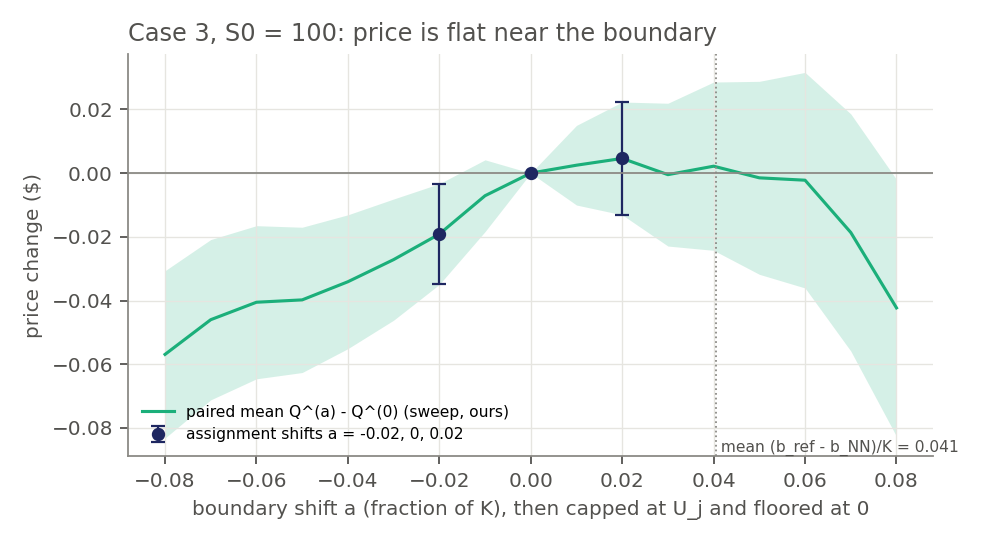

In [5]:
display(pd.read_csv("tables/p5_perturbation.csv"))
display(pd.read_csv("tables/p5_perturbation_sweep_supplementary.csv")[["a","mean_diff","se_diff","applied_shift_mean","frac_paths_changed","cap_binds_dates"]])
Image("figures/p5_perturbation.png")

## 4. Ordering diagnostics with the final policies

In [6]:
display(pd.read_csv("tables/p1_ordering_checks.csv"))

,N,method,A,B,F
0,180,LS,0.0,0.000000,0.200384
1,180,NN,32.0,0.133758,0.150714
2,180,ref,0.0,0.000000,0.000000
3,180,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000
4,360,LS,0.0,0.000000,0.102824
5,360,NN,0.0,0.000000,0.056080
6,360,ref,0.0,0.000000,0.000000
7,360,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000
